In [27]:
import pandas as pd
import numpy as np


filepath = r"/home/lucasedbraga/repositorios/ufjf/mestrado_luedsbr/SRC/SOLVER/DB/getters/intermittent-renewables-production-france.csv"

# Carregar dados brutos
print(f"Carregando: {filepath}")
df = pd.read_csv(filepath)

# Processar data/hora
df['DateTime'] = pd.to_datetime(df['Date and Hour'].str.slice(stop=-6))
df = df.sort_values('DateTime')

# Separar vento e solar
df_wind = df[df['Source'] == 'Wind'].copy()
# Normalizar produção (fator 0-1)
for df_source in [df_wind]:
    if len(df_source) > 0:
        max_prod = df_source['Production'].max()
        if max_prod > 0:
            df_source['Factor'] = df_source['Production'] / max_prod
        else:
            df_source['Factor'] = 0

# Selecionar colunas finais
cols = ['DateTime', 'Production', 'Factor']
df_wind = df_wind[cols].copy()


# Renomear
df_wind.columns = ['timestamp', 'wind_production_mw', 'wind_factor']

print(f"✓ Vento: {len(df_wind)} registros")

Carregando: /home/lucasedbraga/repositorios/ufjf/mestrado_luedsbr/SRC/SOLVER/DB/getters/intermittent-renewables-production-france.csv
✓ Vento: 29904 registros


In [28]:
df_wind.head()

,timestamp,wind_production_mw,wind_factor
172,2020-01-01 00:00:00,3549.0,0.206098
11231,2020-01-01 01:00:00,2952.0,0.171429
9597,2020-01-01 02:00:00,2722.0,0.158072
175,2020-01-01 03:00:00,2753.0,0.159872
116,2020-01-01 04:00:00,2707.0,0.157201


In [29]:
float(df_wind["wind_factor"].sample(1))

/tmp/ipykernel_29201/1728679354.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(df_wind["wind_factor"].sample(1))


0.020441347270615563

In [30]:
import sys
sys.path.append('../STUDIES')
from opf_sql_accessor import load_opf_results

db_path = '../DATA/SMA/resultados_PL.db'
dfs = load_opf_results(db_path)

# Visualizar as tabelas carregadas
dfs.keys()

dict_keys(['resultados_opf', 'detalhes_barras', 'detalhes_geradores', 'detalhes_linhas', 'bess_wind_operacao'])

In [31]:
df_barras = dfs['detalhes_barras']
df_barras.head()

,id,resultado_id,barra_id,tipo_barra,theta_deg,carga_p_mw,carga_q_mvar,geracao_mw,deficit_mw,cmo
0,1,1,1,Slack,0.000000,0.000000,0.0,9.190357e-01,0.000000e+00,0.0
1,2,1,2,PV,-21.062748,0.000000,0.0,8.881784e-16,0.000000e+00,0.0
2,3,1,3,PQ,-31.594122,2.696843,0.0,1.743322e-02,-8.534840e-16,0.0
3,4,2,1,Slack,0.000000,0.000000,0.0,8.833092e-01,0.000000e+00,0.0
4,5,2,2,PV,-20.243956,0.000000,0.0,6.661338e-16,0.000000e+00,0.0


In [41]:
df_barra = df_barras.head(3)
sum(df_barra.carga_p_mw) - sum(df_barra.geracao_mw) - sum(df_barra.deficit_mw)

1.7603739221389454

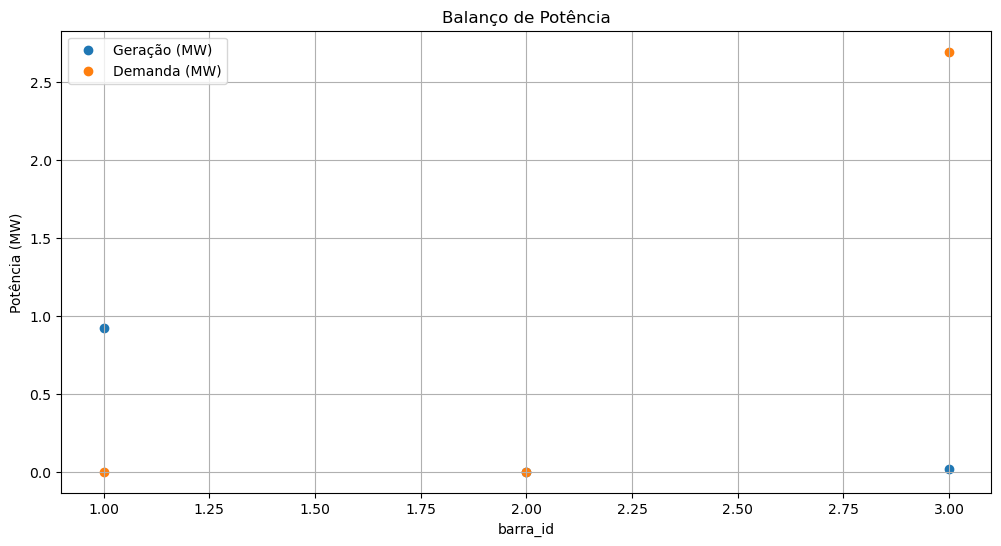

In [33]:
import matplotlib.pyplot as plt



plt.figure(figsize=(12,6))
plt.scatter(df_barra['barra_id'].values, df_barra['geracao_mw'].values, label='Geração (MW)')
plt.scatter(df_barra['barra_id'].values, df_barra['carga_p_mw'].values, label='Demanda (MW)')
plt.title(f'Balanço de Potência')
plt.xlabel('barra_id')
plt.ylabel('Potência (MW)')
plt.legend()
plt.grid()
plt.show()